# **Zee Recommender Business Case Study**


**Overview from the company's perspective** -
Porter is India's Largest Marketplace for Intra-City Logistics. Leader in the country's $40 billion intra-city logistics market, Porter strives to improve the lives of 1,50,000+ driver-partners by providing them with consistent earning & independence. Currently, the company has serviced 5+ million customers

Porter works with a wide range of restaurants for delivering their items directly to the people.



**Problem Statement -**
- Porter has a number of delivery partners available for delivering the food, from various restaurants and wants to get an estimated delivery time that it can provide the customers on the basis of what they are ordering, from where and also the delivery partners.

- This dataset has the required data to train a regression model that will do the delivery time estimation, based on all those features

**About Data** -

Each row in this file corresponds to one unique delivery. Each column corresponds to a feature as explained below.

- market_id : integer id for the market where the restaurant lies
- created_at : the timestamp at which the order was placed
- actual_delivery_time : the timestamp when the order was delivered
- store_primary_category : category for the restaurant
- order_protocol : integer code value for order protocol(how the order was placed ie: through porter, call to restaurant, pre booked, third part etc)
- total_items subtotal : final price of the order
- num_distinct_items : the number of distinct items in the order
- min_item_price : price of the cheapest item in the order
- max_item_price : price of the costliest item in order
- total_onshift_partners : number of delivery partners on duty at the time order was placed
- total_busy_partners : number of delivery partners attending to other tasks
- total_outstanding_orders : total number of orders to be fulfilled at the moment
- estimated_store_to_consumer_driving_duration : approximate travel time from restaurant to customer

Expectation -

As a data scientist at Porter, my task is to analyze the dataset to accurately predict
delivery times for different orders. Your primary goal is to build a regression model using
neural networks, evaluate its performance, and provide insights for optimizing delivery
operations.

# Exploratory Data Analysis

### Observation on Data

In [ ]:
# impoting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('porter_data.csv',)
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


In [3]:
# Shape of the data set
df.shape

(175777, 14)

In [4]:
# Name of each column in dataframe
df.columns

Index(['market_id', 'created_at', 'actual_delivery_time',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

Observation:
 - Data contains mix of data types
 - Seems like 1 missing records for all the columns except market_id & created_at

In [6]:
# check misisng values
df.isnull().sum()

# 1 missing records for all the columns except market_id & created_at

,0
market_id,0
created_at,0
actual_delivery_time,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0
max_item_price,0


In [7]:
# total missing records
df.isnull().sum().sum()

np.int64(0)

Observation -

- There are 12 missing (null) values in the DataFrame, and the result is of type numpy.int64.
- Since, there are only few records, lets remove it from the dataset.

In [8]:
# remove null records
df.dropna(inplace=True)

# check if there is still any missing records
df.isnull().sum().sum()

# all null records have been removed.

np.int64(0)

In [9]:
# check the statistical summary of the data
df.describe(include='all')

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
count,175777.000000,175777,175777,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000
unique,NaN,162649,160344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2015-02-11 19:50:43,2015-02-15 04:18:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.743726,NaN,NaN,35.887949,2.911752,3.204976,2697.111147,2.675060,684.965433,1160.158616,44.918664,41.861381,58.230115,546.077240
std,1.330963,NaN,NaN,20.728254,1.513128,2.674055,1828.554893,1.625681,519.882924,560.828571,34.544724,32.168505,52.731043,218.717798
min,1.000000,NaN,NaN,0.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000
25%,2.000000,NaN,NaN,18.000000,1.000000,2.000000,1412.000000,1.000000,299.000000,799.000000,17.000000,15.000000,17.000000,384.000000
50%,2.000000,NaN,NaN,38.000000,3.000000,3.000000,2224.000000,2.000000,595.000000,1095.000000,37.000000,35.000000,41.000000,544.000000
75%,4.000000,NaN,NaN,55.000000,4.000000,4.000000,3410.000000,3.000000,942.000000,1395.000000,66.000000,63.000000,85.000000,703.000000


In [10]:
# check the value counts for market_id
df['order_protocol'].value_counts()

,count
order_protocol,
1.0,48404
3.0,47125
5.0,41415
2.0,20890
4.0,17246
6.0,678
7.0,19


Observation

- Market id values lies between 1 and 6, so it means that there are six market segments where porter work on.
- store_primary_category - having values between 0 and 72.
- Order protocol - values between 1 and 7.
- Avg order price is ~2743 with ~3 distinct items.
- Min value of some columns like total_onshift_dashers, total_busy_dashers, total_outstanding_orders etc. having negative value. The value of these columns should be positive. Will check later for the same.


### Univariate Analysis

In [11]:
cols = list(df.select_dtypes(include=['int64', 'float64']).columns)

len(cols)
# total 12 columns

12

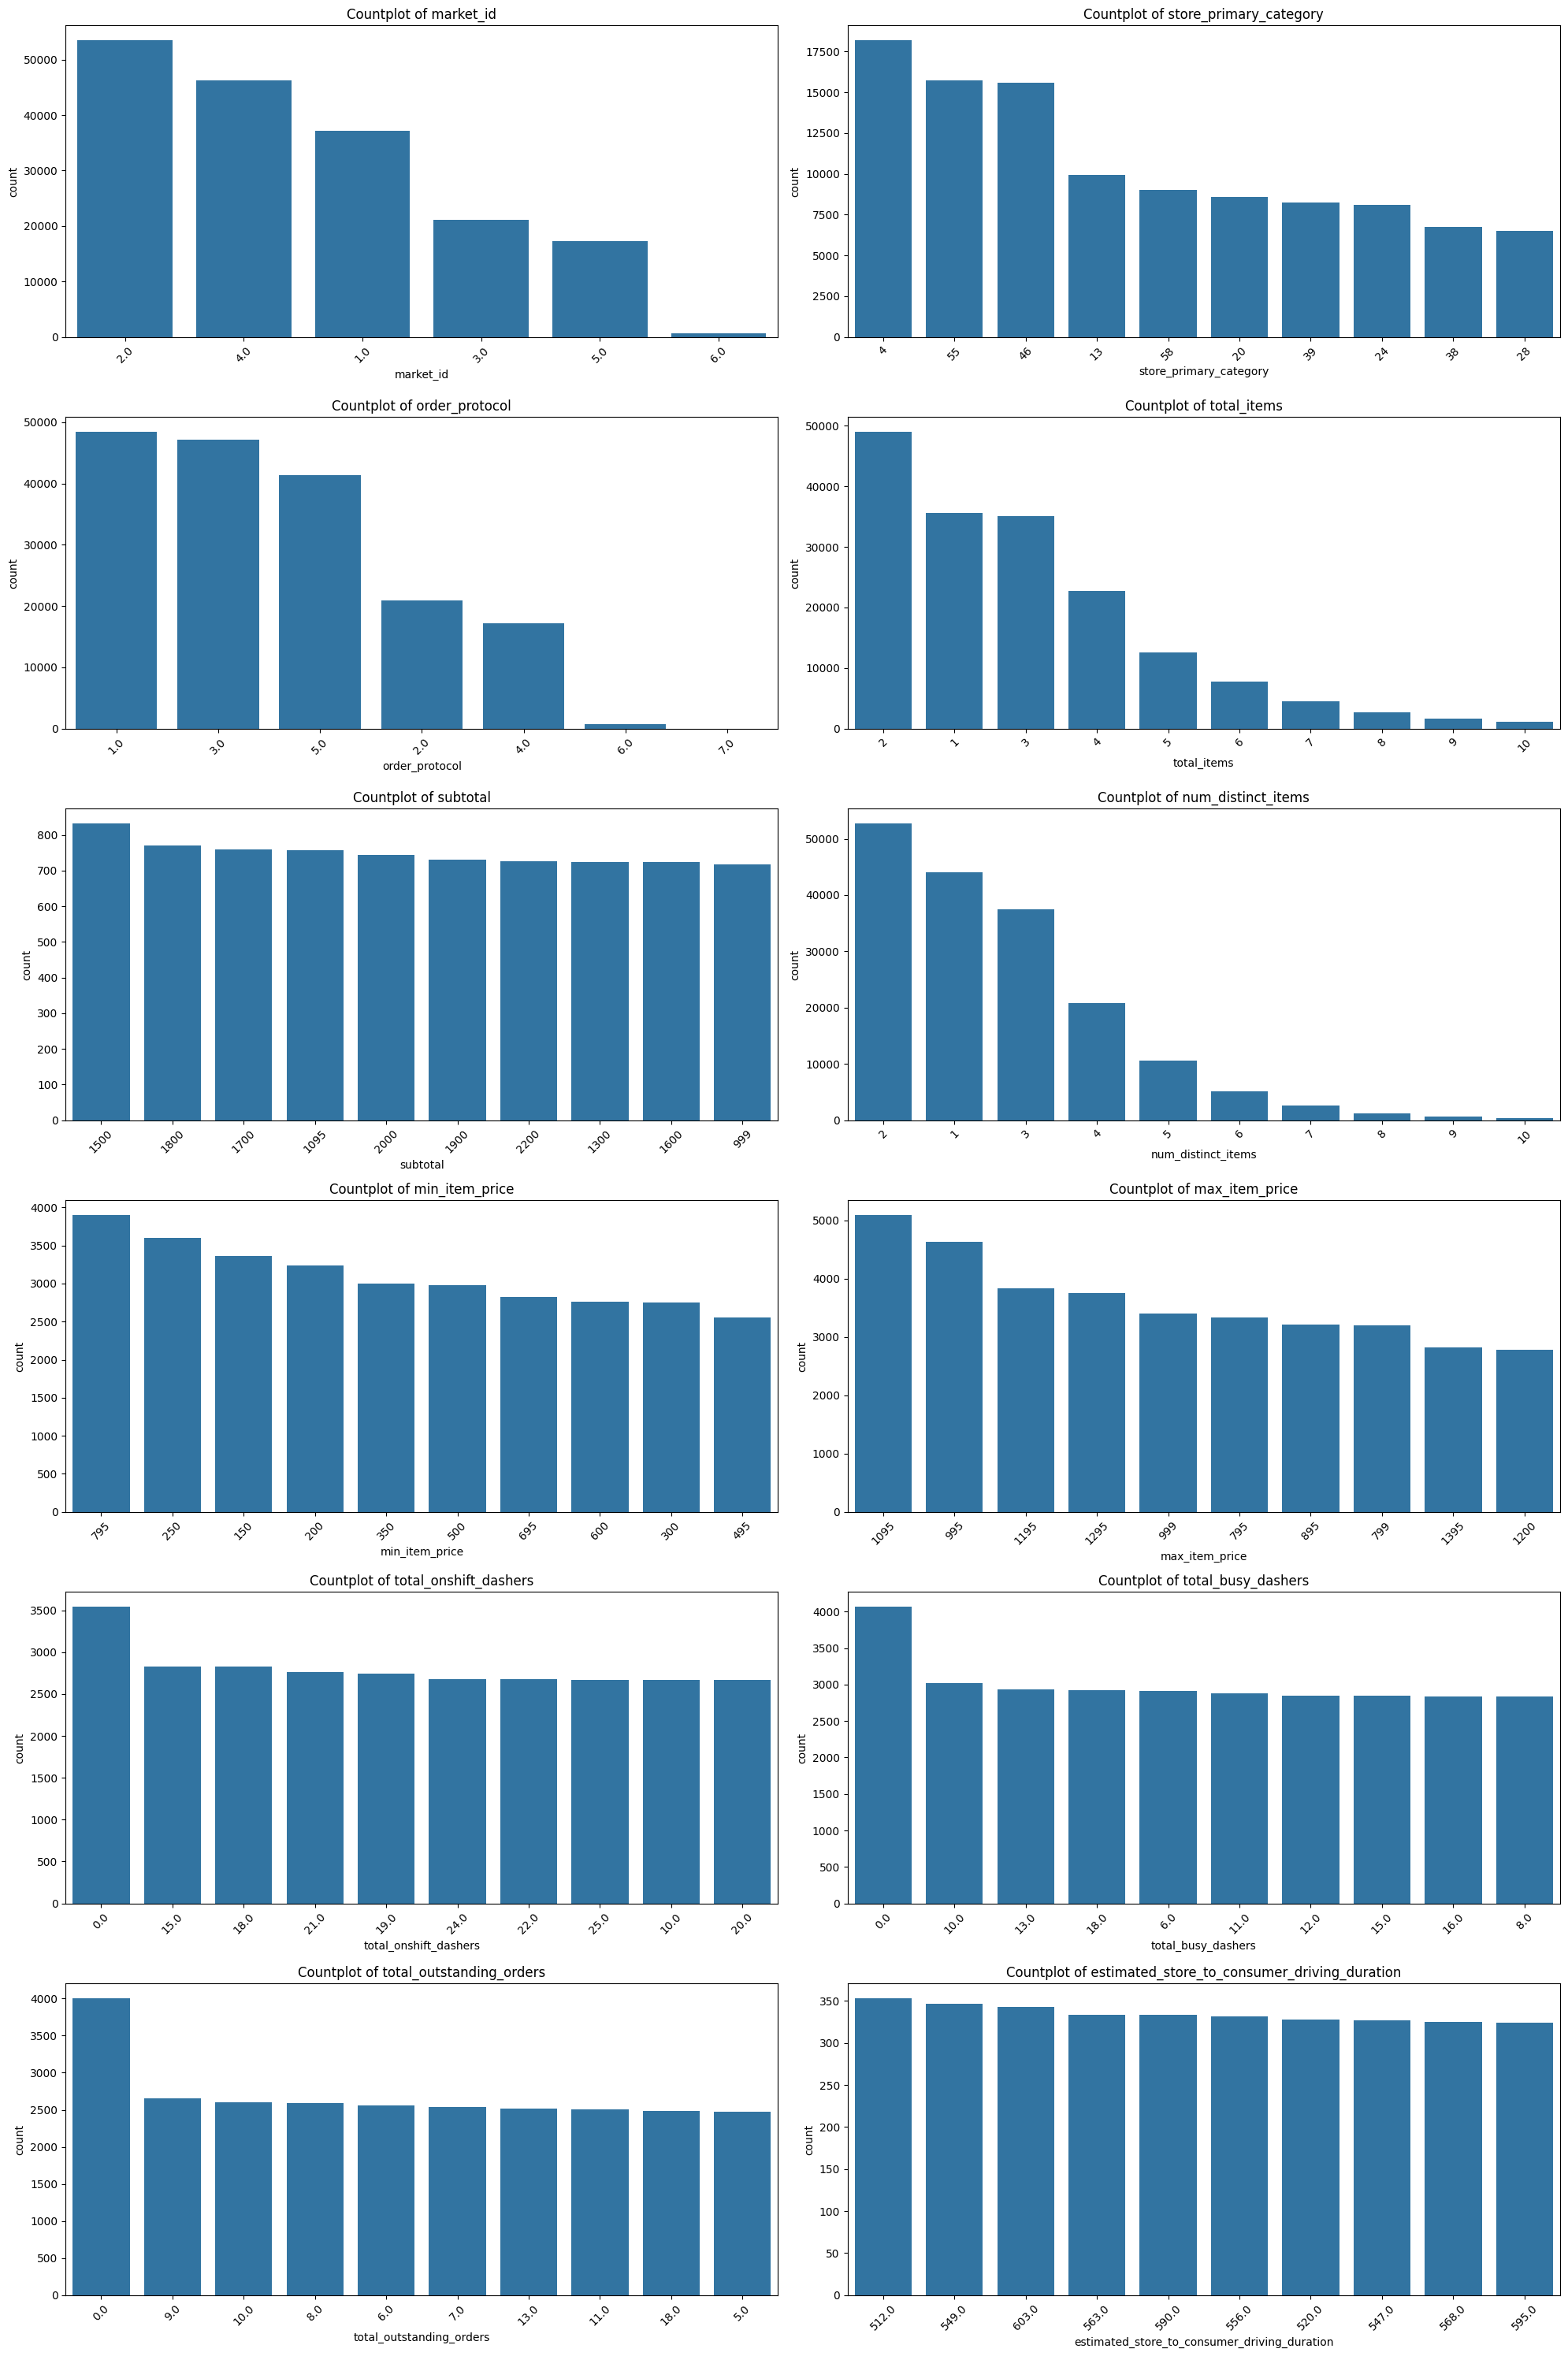

In [12]:
top_n = 10  # Top 10 categories

fig, axes = plt.subplots(6, 2, figsize=(20, 30))
axes = axes.flatten()

for i, col in enumerate(cols):
    top_categories = df[col].value_counts().nlargest(top_n).index
    filtered_df = df[df[col].isin(top_categories)]

    sns.countplot(x=col, data=filtered_df, order=top_categories, ax=axes[i])
    axes[i].set_title(f'Countplot of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Observation-

- Market id 1,2 & 4 where most of the orders comes from.
- Columns total outstanding ordes, total busy dashers and onshift dashers having lot of records having 0 value. Need to check what is this?
- Mostly customers orders having 1-3 distinct items.

In [13]:
# check the columns having negative values and extract only those columns
df_bol = df[cols].apply(lambda x: (x < 0).sum()>0)

# if the value is true then take only those columns
df_neg_value_columns = df_bol[df_bol].index


In [14]:
# check the count of negative values from these negative columns
df[df_neg_value_columns].apply(lambda x: (x < 0).sum())

,0
min_item_price,12
total_onshift_dashers,21
total_busy_dashers,21
total_outstanding_orders,41


Observation - there are only few negative values, so better to remove from the dataset, that doesn't make any difference.

In [15]:
# remove negative values from these columns from the dataset
cols = ['min_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders']
df = df[(df[cols] >= 0).all(axis=1)]

In [16]:
# check the columns having negative values or not?
df[cols].apply(lambda x: (x < 0).sum()>0)

,0
min_item_price,False
total_onshift_dashers,False
total_busy_dashers,False
total_outstanding_orders,False


In [17]:
# check the shapr of the data
df.shape

(175687, 14)

### Bivariate Analysis

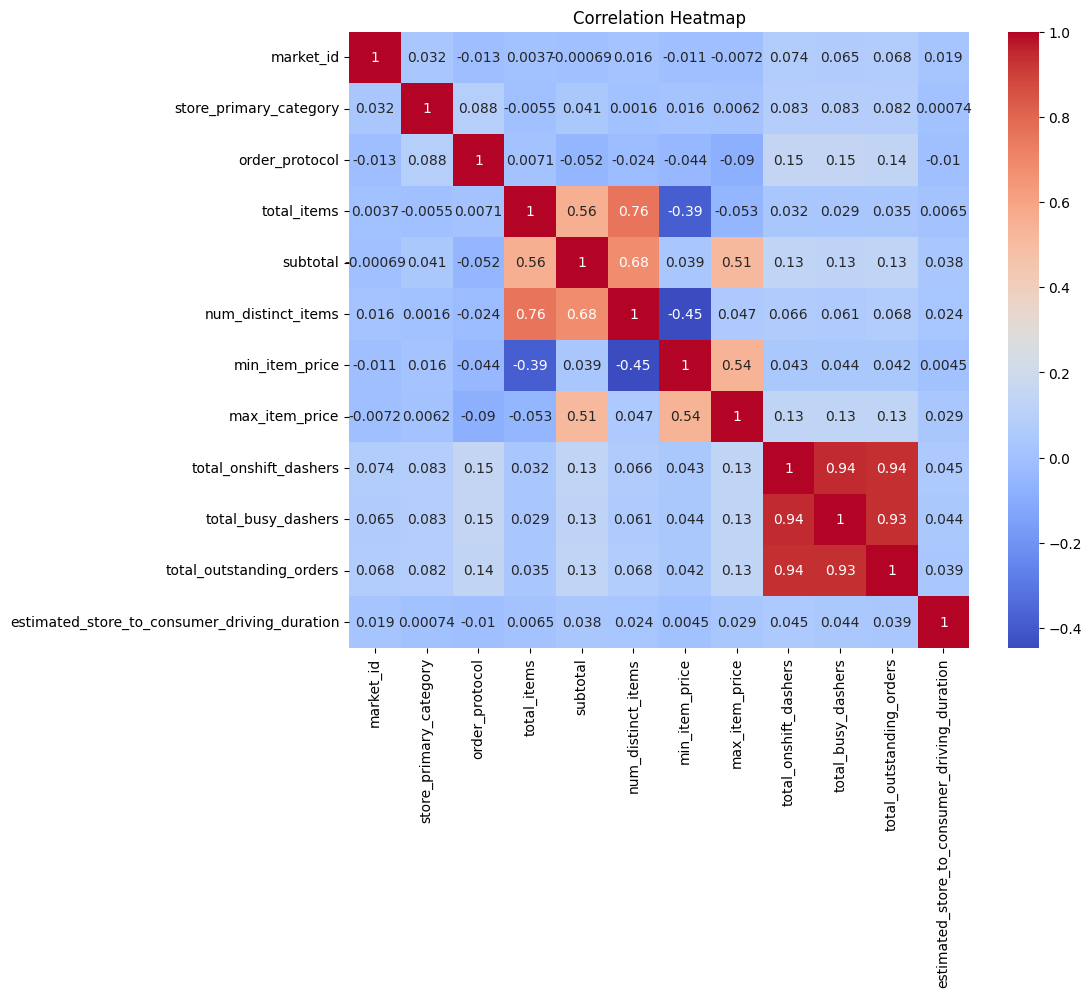

In [18]:
# Heatmap for continuous variable
cols = list(df.select_dtypes(include=['int64', 'float64']).columns)
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Observation - Good correlation between estimated store to consumer driving duration.

In [26]:
# create 'estimated_delivery_time', is to be derived from the difference between 'created_at' and 'actual_delivery_time'.
df['estimated_delivery_time'] = (pd.to_datetime(df['actual_delivery_time']) - pd.to_datetime(df['created_at'])).dt.total_seconds() / 60
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,estimated_delivery_time
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,44.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,55.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,59.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,46.0


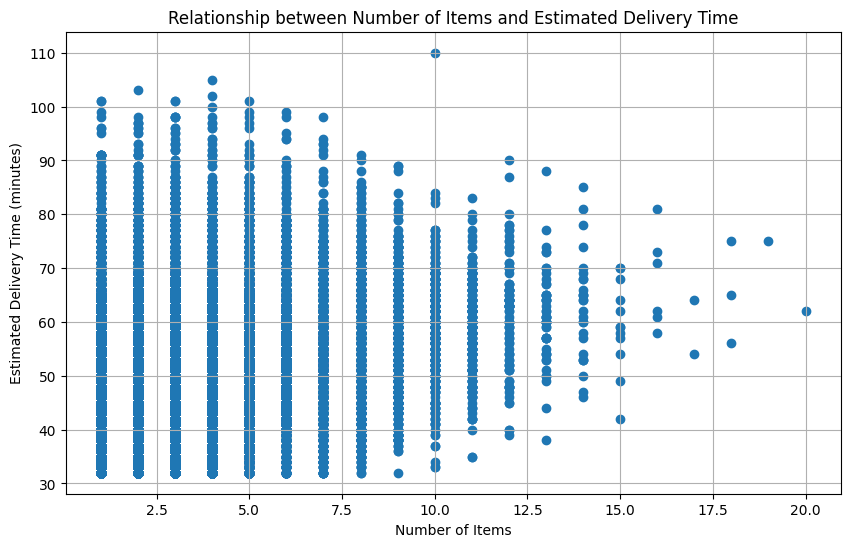

In [28]:
# create the scatter plot analyze the relationship between the number of items and delivery time.
plt.figure(figsize=(10, 6))
plt.scatter(df['num_distinct_items'], df['estimated_delivery_time'])
plt.xlabel('Number of Items')
plt.ylabel('Estimated Delivery Time (minutes)')
plt.title('Relationship between Number of Items and Estimated Delivery Time')
plt.grid(True)
plt.show()

Observation - No such relationship relationship between the number of items and delivery time.

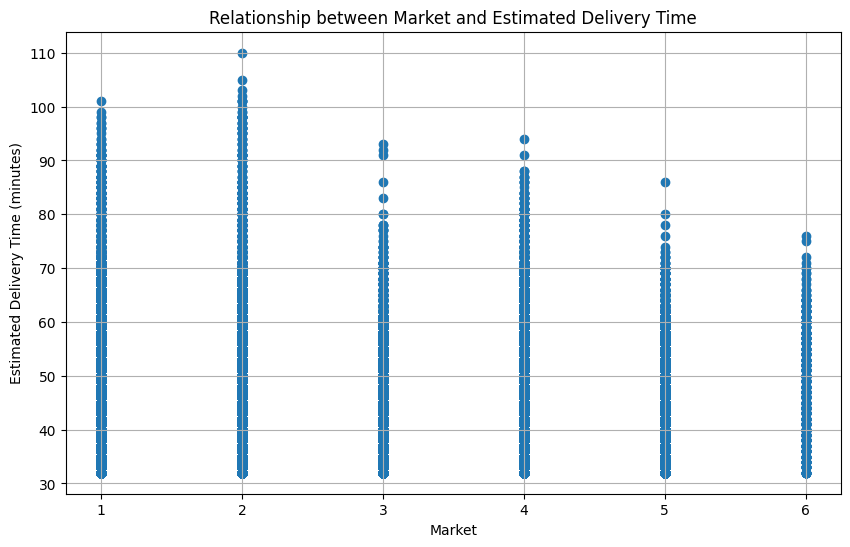

In [31]:
# create the scatter plot analyze the relationship between the market_id and delivery time.
plt.figure(figsize=(10, 6))
plt.scatter(df['market_id'], df['estimated_delivery_time'])
plt.xlabel('Market')
plt.ylabel('Estimated Delivery Time (minutes)')
plt.title('Relationship between Market and Estimated Delivery Time')
plt.grid(True)
plt.show()

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175687 entries, 0 to 175776
Data columns (total 15 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175687 non-null  float64
 1   created_at                                    175687 non-null  object 
 2   actual_delivery_time                          175687 non-null  object 
 3   store_primary_category                        175687 non-null  int64  
 4   order_protocol                                175687 non-null  float64
 5   total_items                                   175687 non-null  int64  
 6   subtotal                                      175687 non-null  int64  
 7   num_distinct_items                            175687 non-null  int64  
 8   min_item_price                                175687 non-null  int64  
 9   max_item_price                                175687 

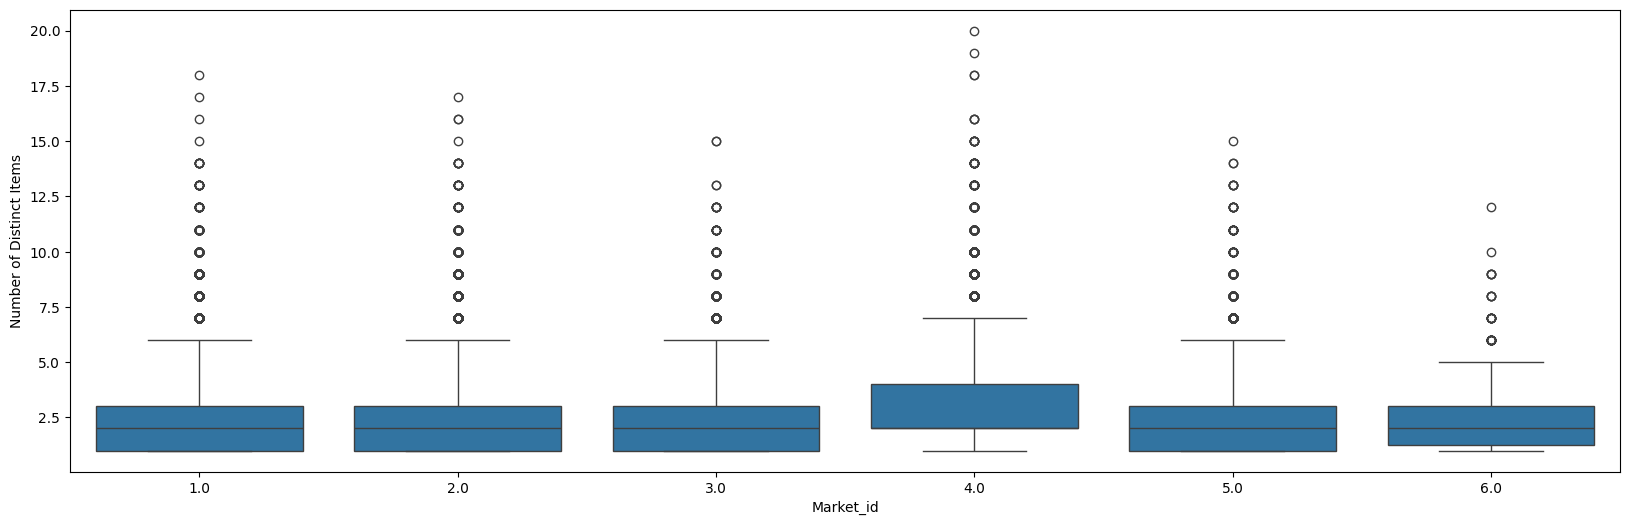

In [38]:
# Box plot the market id vs num_distinct_items
plt.figure(figsize=(20, 6))
sns.boxplot(x='market_id', y='num_distinct_items', data=df)
plt.xlabel('Market_id')
plt.ylabel('Number of Distinct Items')
plt.show()

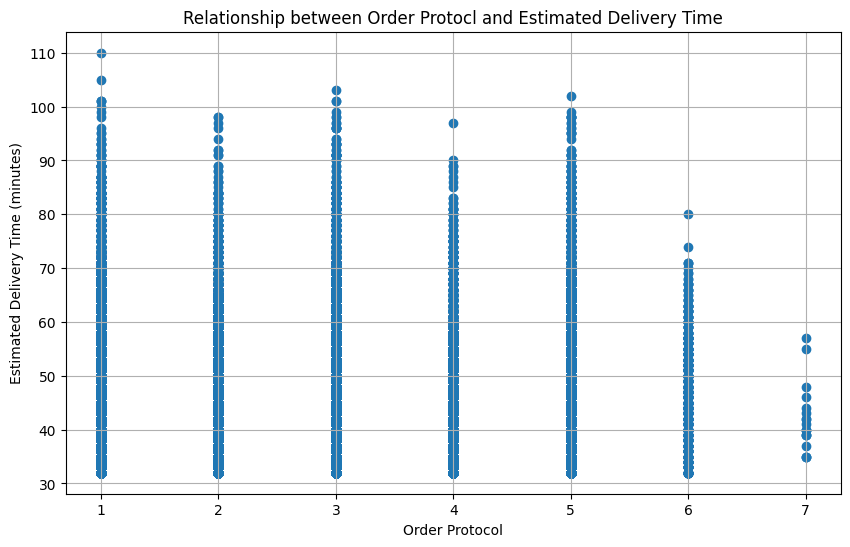

In [40]:
# create the scatter plot analyze the relationship between the protocol and delivery time.
plt.figure(figsize=(10, 6))
plt.scatter(df['order_protocol'], df['estimated_delivery_time'])
plt.xlabel('Order Protocol')
plt.ylabel('Estimated Delivery Time (minutes)')
plt.title('Relationship between Order Protocl and Estimated Delivery Time')
plt.grid(True)
plt.show()

<Axes: xlabel='order_time_bucket', ylabel='count'>

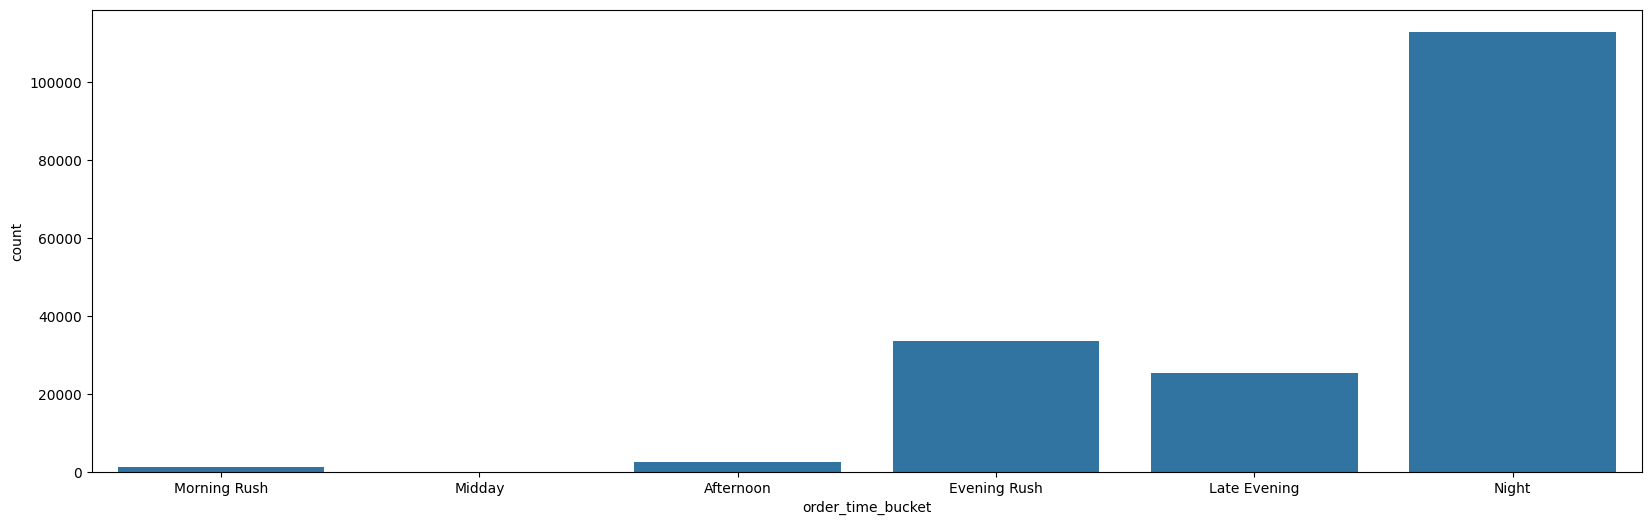

In [59]:
# check when the order placed

# first create the bin for created_at like peak hours based on time when order placed
df['created_at'] = pd.to_datetime(df['created_at'])
df['order_hour'] = df['created_at'].dt.hour
def get_time_bucket(hour):
    if 6 <= hour < 10:
        return 'Morning Rush'
    elif 10 <= hour < 14:
        return 'Midday'
    elif 14 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening Rush'
    elif 21 <= hour < 24:
        return 'Late Evening'
    else:
        return 'Night'

df['order_time_bucket'] = df['order_hour'].apply(get_time_bucket)
plt.figure(figsize=(20, 6))
sns.countplot(x='order_time_bucket', data=df, order=['Morning Rush', 'Midday', 'Afternoon', 'Evening Rush', 'Late Evening', 'Night'])

Observation - Most of the orders placed on post evening espc. at night time.

<Axes: xlabel='order_time_bucket', ylabel='estimated_delivery_time'>

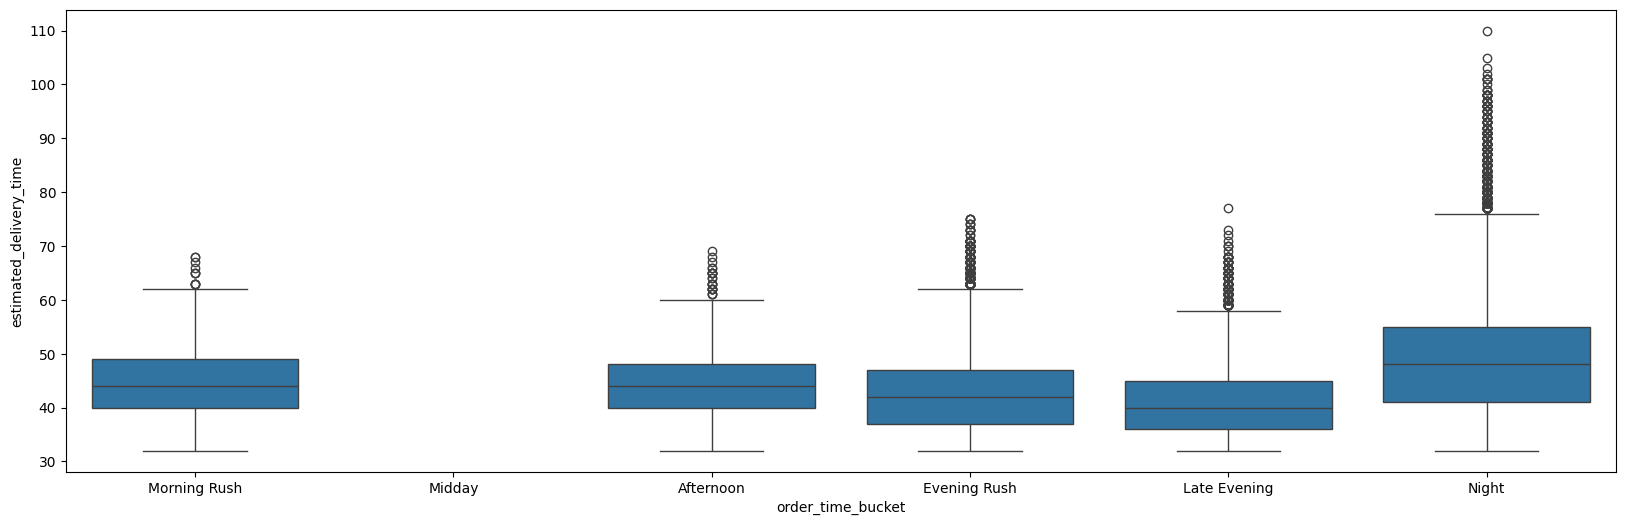

In [63]:
# lets check the relationshop between the order bucket vs delivery time
plt.figure(figsize=(20, 6))
sns.boxplot(x='order_time_bucket', y='estimated_delivery_time', data=df, order=['Morning Rush', 'Midday', 'Afternoon', 'Evening Rush', 'Late Evening', 'Night'])

Observation - Since there are lot of orders at the night time, hence the delivery of the orders are also taking the longer time.

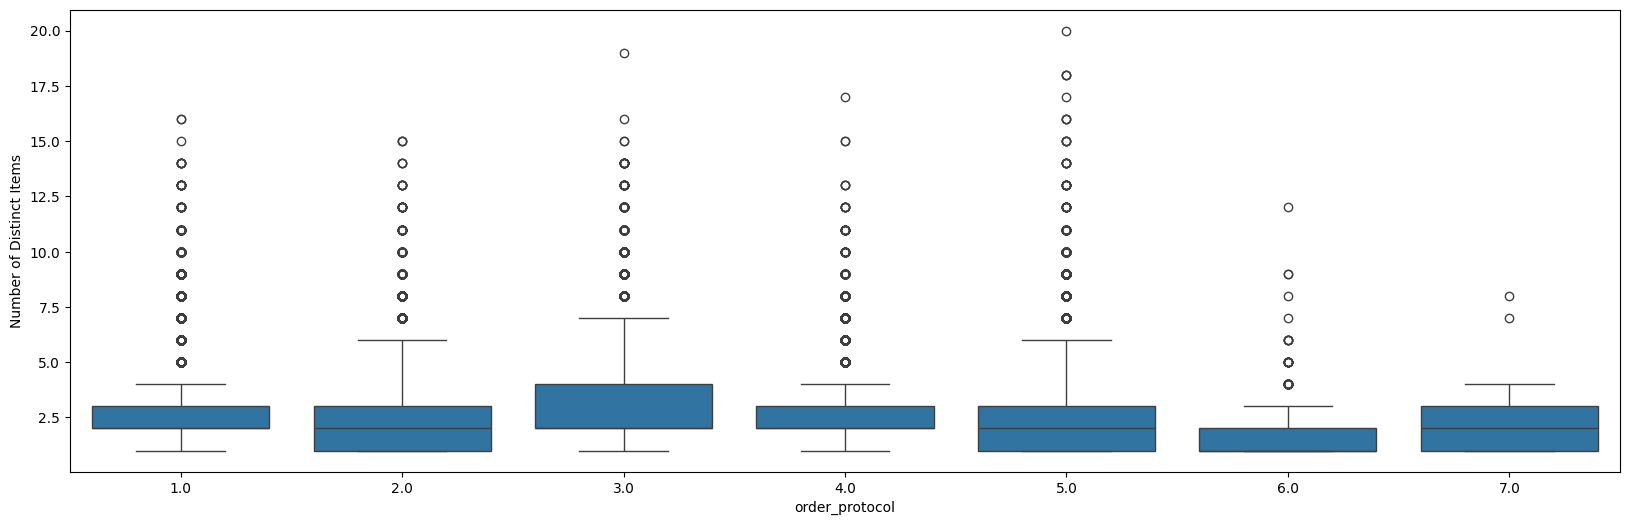

In [41]:
# Box plot the order protocol vs num_distinct_items
plt.figure(figsize=(20, 6))
sns.boxplot(x='order_protocol', y='num_distinct_items', data=df)
plt.xlabel('order_protocol')
plt.ylabel('Number of Distinct Items')
plt.show()

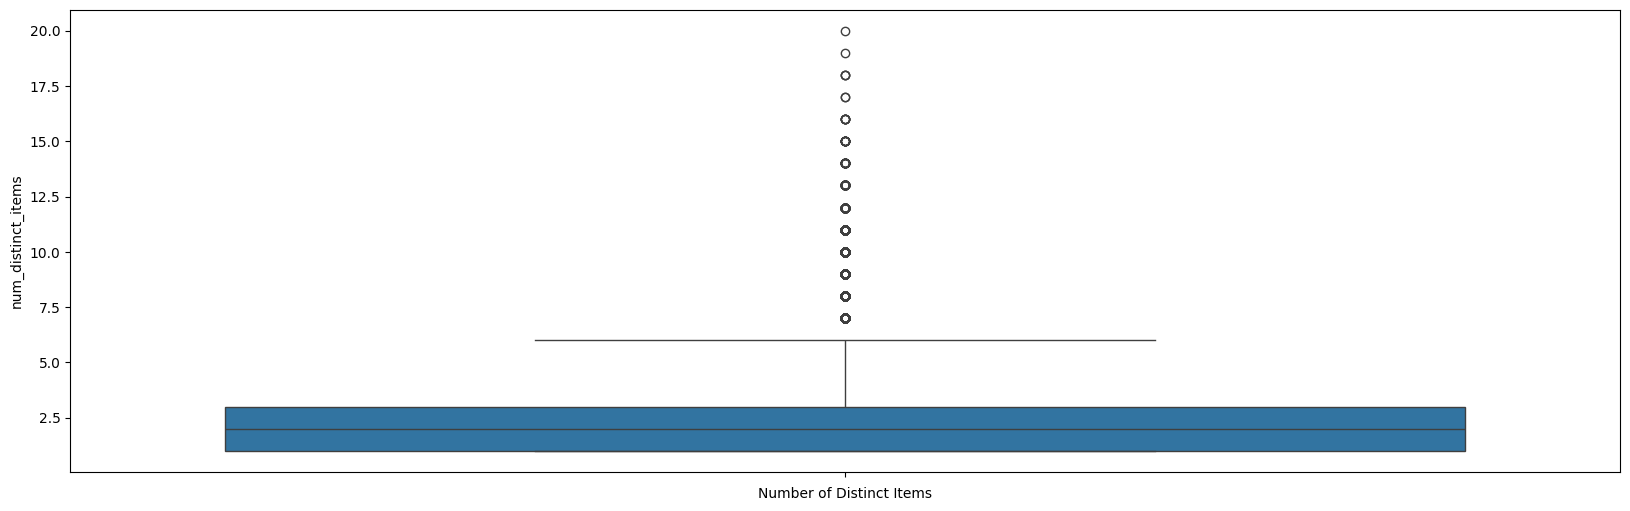

In [43]:
# check the overall distribution of num_distinct_items
plt.figure(figsize=(20, 6))
sns.boxplot(y='num_distinct_items', data=df)
plt.xlabel('Number of Distinct Items')
plt.show()

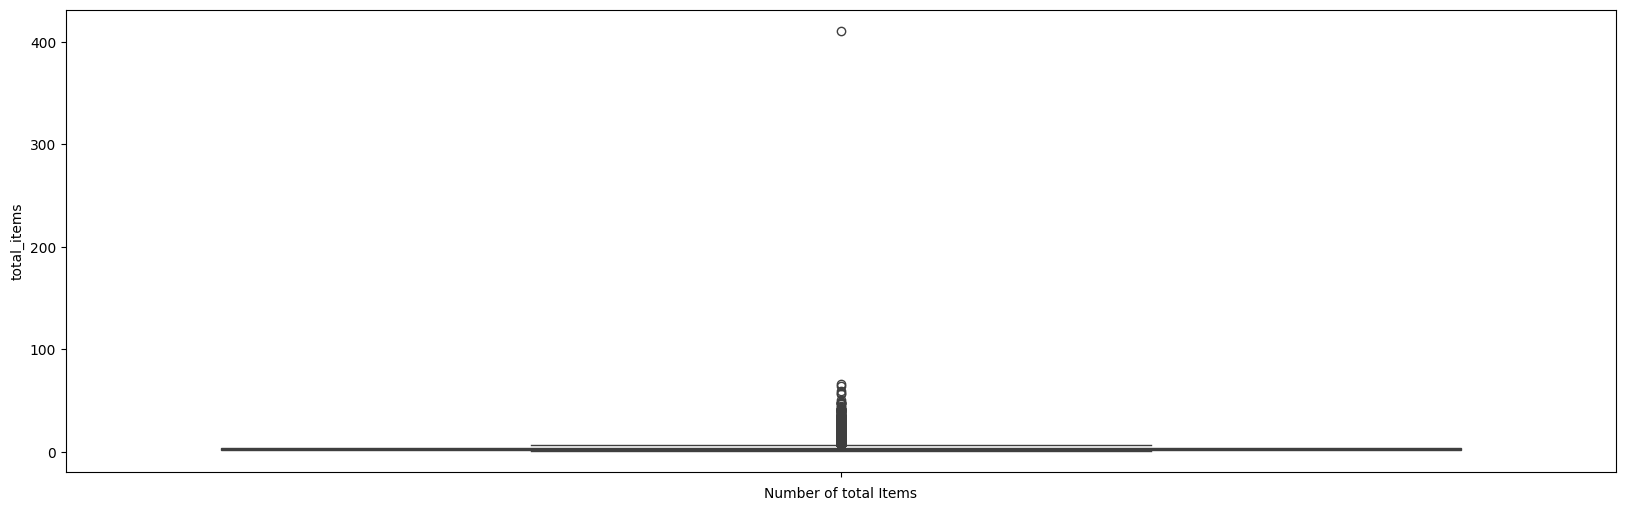

In [47]:
# check the overall distribution of total items
plt.figure(figsize=(20, 6))
sns.boxplot(y='total_items', data=df)
plt.xlabel('Number of total Items')
plt.show()

Observation - seems like most of the orders distinct items are up to 7, so need to treat the outliers.

# Data Processing

### Treat Outliers

In [98]:
# To treat outlier, check skewness against no of items
df['total_items'].skew()

np.float64(23.334969448920177)

Observation, per box plot and skew value > o then it is a right skewed.
Below is the portion of the code, to remove the outliers

In [126]:
# Check the outliers statistically

Q1 = df['total_items'].quantile(0.25)
Q3 = df['total_items'].quantile(0.75)

IQR = Q3-Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR


outliers = df[(df['total_items'] < lower_bound) | (df['total_items'] > upper_bound)]
outliers.shape[0] / df.shape[0]
# ~4% records are outliers

0.04824489006016382

In [127]:
# remove the outliers
df_cleaned = df[(df['total_items'] >= lower_bound) & (df['total_items'] <= upper_bound)]
df_cleaned.shape

# final records = 167211

(167211, 17)

### Check Duplicates

In [101]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 167211 entries, 0 to 175776
Data columns (total 17 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     167211 non-null  float64       
 1   created_at                                    167211 non-null  datetime64[ns]
 2   actual_delivery_time                          167211 non-null  object        
 3   store_primary_category                        167211 non-null  int64         
 4   order_protocol                                167211 non-null  float64       
 5   total_items                                   167211 non-null  int64         
 6   subtotal                                      167211 non-null  int64         
 7   num_distinct_items                            167211 non-null  int64         
 8   min_item_price                                167211 non-nu

In [102]:
# check duplicate records
df_cleaned.duplicated().sum()

# there is no duplicate records

np.int64(0)

### Feature Engineering

In [128]:
# lets create the day of the week from created at column
df_cleaned['created_at'] = pd.to_datetime(df_cleaned['created_at'])
df_cleaned['order_day'] = df_cleaned['created_at'].dt.day_name()
df_cleaned['order_day'].unique()

array(['Friday', 'Tuesday', 'Monday', 'Thursday', 'Sunday', 'Saturday',
       'Wednesday'], dtype=object)

Text(0, 0.5, 'Count')

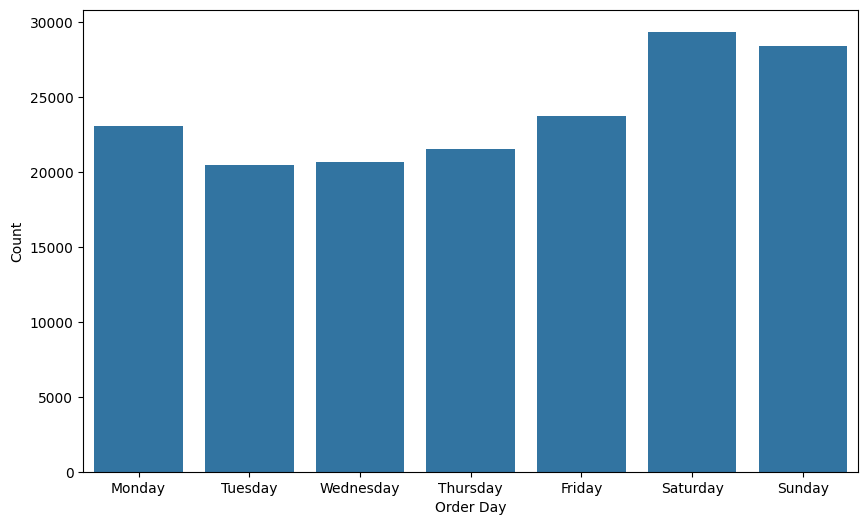

In [129]:
# see the distribution of the data for the order day
plt.figure(figsize=(10, 6))
sns.countplot(x='order_day', data=df_cleaned, order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.xlabel('Order Day')
plt.ylabel('Count')

In [130]:
# lets create the order month column  fromcreated at column
df_cleaned['created_at'] = pd.to_datetime(df_cleaned['created_at'])
df_cleaned['order_month'] = df_cleaned['created_at'].dt.month_name()
df_cleaned['order_month'].unique()

array(['February', 'January'], dtype=object)

Observation - The customers generally placed the order on weekends and Monday
Since there are two month of the data i.e Jan and Feb, so lets drop this column

In [131]:
# check the unique value of total_busy_dashers
df_cleaned['total_busy_dashers'].unique(), df_cleaned['total_busy_dashers'].nunique()

(array([ 14.,   2.,   6.,   5.,   1.,   4.,   9.,  24.,  13.,  19.,  17.,
         11.,  21.,  25.,  16.,  18., 112., 129., 119.,  30.,  15.,  33.,
         22.,  37.,  29.,  12.,  23.,  31.,  34.,  20.,  62.,  28.,  44.,
         39.,  32.,  53.,  52.,  59.,  57.,   7.,   3.,   8.,  10., 100.,
         72.,  81., 106.,  84., 122., 109.,  54.,  89., 103.,  91.,  75.,
        107., 102.,  38.,  96.,  80.,  94.,  64., 117., 125., 110., 128.,
         27.,  35.,  70.,  74.,  40.,  97.,  77.,  61., 116., 123.,  42.,
         26.,  95.,  68.,  73., 108.,  55.,  78.,  67.,  69.,  99.,  45.,
         63.,  71.,  50.,  48.,  41.,  66., 127.,  58.,   0.,  79.,  85.,
         88.,  98., 118.,  90.,  36., 121.,  65.,  60.,  47.,  49.,  43.,
         46.,  93., 132., 104., 114., 124.,  56.,  51.,  83.,  76., 101.,
         92., 130.,  86., 138., 136.,  82.,  87., 143., 146., 131., 113.,
        120., 115., 148., 105., 126., 111., 137., 135., 141., 133., 145.,
        139., 134., 142., 150., 144., 

In [132]:
# check the unique value of total_onshift_dashers
df_cleaned['total_onshift_dashers'].unique(), df_cleaned['total_onshift_dashers'].nunique()

(array([ 33.,   1.,   8.,   5.,   4.,   6.,  24.,  12.,  19.,  21.,  22.,
         16.,  27.,  13., 117., 130., 121.,  34.,  18.,  17.,  38.,  20.,
         15.,  26.,  30.,  35.,  11.,  14.,  32.,  29.,  25.,  23.,  61.,
         41.,  58.,  51.,  57.,  60.,   7.,   3.,   2.,   9., 108.,  72.,
         39.,  89., 112.,  55., 126.,  80.,  69., 125., 113., 105.,  98.,
         90.,  87.,  74.,  84.,  91.,  96., 123., 101., 119., 129.,  66.,
         81.,  43.,  70.,  65.,  77., 114., 116., 102.,  76.,  67.,  64.,
         88.,  86.,  73.,  63.,  46.,  28.,  36.,  47., 110.,  97.,  42.,
         79.,  49.,  50.,  92., 103.,  44.,  68.,   0., 107.,  94.,  78.,
         62.,  71., 128., 104.,  56.,  45.,  31., 100.,  53.,  40.,  37.,
        115., 109.,  99.,  85., 118.,  10.,  59.,  54.,  52.,  48., 132.,
        127., 133., 131., 149.,  93., 111.,  95.,  82., 120., 134., 124.,
        106., 137., 136.,  83., 152., 147.,  75., 144., 150., 145., 155.,
        135., 151., 140., 141., 143., 

Observation - there are more than 150 unique values of both total_onshift_dashers & total_busy_dashers columns, lets convert into bins - which help the model to train better

In [108]:
df_cleaned['total_onshift_dashers'].min(), df_cleaned['total_onshift_dashers'].max()

(0.0, 171.0)

In [109]:
df_cleaned['total_busy_dashers'].min(), df_cleaned['total_busy_dashers'].max()

(0.0, 154.0)

The range of values

- Between 0 and 154 for busy dashers
- Between 0 and 171 for onshift dashers

Lets create the bin accordingly

In [133]:
# create the bin data for both total_onshift_dashers & total_busy_dashers columns
# Create bins of size 10 (e.g., 1-10, 11-20, ...)
bins_busy = np.arange(0, 160 + 10, 10)  # Up to 160 to cover 154
labels_busy = [f"{i+1}-{i+10}" for i in bins_busy[:-1]]  # 1-based labels

df_cleaned['busy_dashers_bin'] = pd.cut(df_cleaned['total_busy_dashers'], bins=bins_busy, labels=labels_busy, include_lowest=True)

bins_onshift = np.arange(0, 180 + 10, 10)  # Up to 180 to cover 171
labels_onshift = [f"{i+1}-{i+10}" for i in bins_onshift[:-1]]

df_cleaned['onshift_dashers_bin'] = pd.cut(df_cleaned['total_onshift_dashers'], bins=bins_onshift, labels=labels_onshift, include_lowest=True)


In [134]:
df_cleaned['onshift_dashers_bin'].unique(), df_cleaned['onshift_dashers_bin'].nunique()

(['31-40', '1-10', '21-30', '11-20', '111-120', ..., '131-140', '141-150', '151-160', '171-180', '161-170']
 Length: 18
 Categories (18, object): ['1-10' < '11-20' < '21-30' < '31-40' ... '141-150' < '151-160' < '161-170' <
                           '171-180'],
 18)

In [135]:
df_cleaned['busy_dashers_bin'].unique(), df_cleaned['busy_dashers_bin'].nunique()

(['11-20', '1-10', '21-30', '111-120', '121-130', ..., '81-90', '101-110', '131-140', '141-150', '151-160']
 Length: 16
 Categories (16, object): ['1-10' < '11-20' < '21-30' < '31-40' ... '121-130' < '131-140' < '141-150' <
                           '151-160'],
 16)

Observation - There are 16 & 18 distinct values for busy_dashers_bin and onshift_dashers_bin columns

In [136]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 167211 entries, 0 to 175776
Data columns (total 21 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     167211 non-null  float64       
 1   created_at                                    167211 non-null  datetime64[ns]
 2   actual_delivery_time                          167211 non-null  object        
 3   store_primary_category                        167211 non-null  int64         
 4   order_protocol                                167211 non-null  float64       
 5   total_items                                   167211 non-null  int64         
 6   subtotal                                      167211 non-null  int64         
 7   num_distinct_items                            167211 non-null  int64         
 8   min_item_price                                167211 non-nu

In [137]:
# convert colnvert to categorical
cols = ['order_time_bucket','order_day','order_month', 'order_protocol', 'store_primary_category','market_id']
df_cleaned[cols] = df_cleaned[cols].astype('category')

In [138]:
# Convert onject to Numberic
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
text_cols = df_cleaned.select_dtypes(include=['object']).columns

for col in text_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

In [139]:
df_cleaned.info()

# now all columns are either category, numeric or datetime

<class 'pandas.core.frame.DataFrame'>
Index: 167211 entries, 0 to 175776
Data columns (total 21 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     167211 non-null  category      
 1   created_at                                    167211 non-null  datetime64[ns]
 2   actual_delivery_time                          167211 non-null  int64         
 3   store_primary_category                        167211 non-null  category      
 4   order_protocol                                167211 non-null  category      
 5   total_items                                   167211 non-null  int64         
 6   subtotal                                      167211 non-null  int64         
 7   num_distinct_items                            167211 non-null  int64         
 8   min_item_price                                167211 non-nu

### Data Preparation for Modeling

In [140]:
# lets drop the unnecessary columns
drop_col = ['created_at', 'actual_delivery_time', 'total_onshift_dashers', 'total_busy_dashers', 'order_month', 'order_hour', 'total_onshift_dashers', 'total_busy_dashers']
df_cleaned.drop(drop_col, axis=1, inplace=True)

In [141]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 167211 entries, 0 to 175776
Data columns (total 15 columns):
 #   Column                                        Non-Null Count   Dtype   
---  ------                                        --------------   -----   
 0   market_id                                     167211 non-null  category
 1   store_primary_category                        167211 non-null  category
 2   order_protocol                                167211 non-null  category
 3   total_items                                   167211 non-null  int64   
 4   subtotal                                      167211 non-null  int64   
 5   num_distinct_items                            167211 non-null  int64   
 6   min_item_price                                167211 non-null  int64   
 7   max_item_price                                167211 non-null  int64   
 8   total_outstanding_orders                      167211 non-null  float64 
 9   estimated_store_to_consumer_driving_durati

In [142]:
# lets do the encoding for the categorical variables

# see the # of unique values for the below columns
for col in df_cleaned.columns:
    print(f"{col}: {df_cleaned[col].nunique()}")


market_id: 6
store_primary_category: 73
order_protocol: 7
total_items: 7
subtotal: 6944
num_distinct_items: 7
min_item_price: 2223
max_item_price: 2548
total_outstanding_orders: 273
estimated_store_to_consumer_driving_duration: 1314
estimated_delivery_time: 73
order_time_bucket: 5
order_day: 7
busy_dashers_bin: 16
onshift_dashers_bin: 18


In [143]:
# Step 1: Define columns ---
onehot_cols = [
    'market_id',
    'order_protocol',
    'order_time_bucket',
    'order_day'
]

# Step 2: One-hot encode low-cardinality categorical columns ---
df_cleaned = pd.get_dummies(df_cleaned, columns=onehot_cols, drop_first=True)

In [144]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 167211 entries, 0 to 175776
Data columns (total 32 columns):
 #   Column                                        Non-Null Count   Dtype   
---  ------                                        --------------   -----   
 0   store_primary_category                        167211 non-null  category
 1   total_items                                   167211 non-null  int64   
 2   subtotal                                      167211 non-null  int64   
 3   num_distinct_items                            167211 non-null  int64   
 4   min_item_price                                167211 non-null  int64   
 5   max_item_price                                167211 non-null  int64   
 6   total_outstanding_orders                      167211 non-null  float64 
 7   estimated_store_to_consumer_driving_duration  167211 non-null  float64 
 8   estimated_delivery_time                       167211 non-null  float64 
 9   busy_dashers_bin                          

In [145]:
# Target Encoding
target_encode_cols = [
    'store_primary_category',
    'busy_dashers_bin',
    'onshift_dashers_bin'
]

target_col = 'estimated_delivery_time'
# Target encoding
for col in target_encode_cols:
    mean_map = df_cleaned.groupby(col)[target_col].mean()
    df_cleaned[col + '_te'] = df_cleaned[col].map(mean_map)

# Drop original categorical columns (optional)
df_cleaned.drop(columns=target_encode_cols, inplace=True)

In [146]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 167211 entries, 0 to 175776
Data columns (total 32 columns):
 #   Column                                        Non-Null Count   Dtype   
---  ------                                        --------------   -----   
 0   total_items                                   167211 non-null  int64   
 1   subtotal                                      167211 non-null  int64   
 2   num_distinct_items                            167211 non-null  int64   
 3   min_item_price                                167211 non-null  int64   
 4   max_item_price                                167211 non-null  int64   
 5   total_outstanding_orders                      167211 non-null  float64 
 6   estimated_store_to_consumer_driving_duration  167211 non-null  float64 
 7   estimated_delivery_time                       167211 non-null  float64 
 8   market_id_2.0                                 167211 non-null  bool    
 9   market_id_3.0                             

In [147]:
df_cleaned.head()

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_outstanding_orders,estimated_store_to_consumer_driving_duration,estimated_delivery_time,market_id_2.0,market_id_3.0,...,order_time_bucket_Night,order_day_Monday,order_day_Saturday,order_day_Sunday,order_day_Thursday,order_day_Tuesday,order_day_Wednesday,store_primary_category_te,busy_dashers_bin_te,onshift_dashers_bin_te
0,4,3441,4,557,1239,21.0,861.0,47.0,False,False,...,False,False,False,False,False,False,False,45.786747,44.787938,43.105724
1,1,1900,1,1400,1400,2.0,690.0,44.0,True,False,...,False,False,False,False,False,True,False,44.242820,46.022869,46.903549
2,4,4771,3,820,1604,18.0,289.0,55.0,True,False,...,True,True,False,False,False,False,False,47.289760,46.022869,46.903549
3,1,1525,1,1525,1525,8.0,795.0,59.0,False,False,...,True,False,False,False,True,False,False,48.954082,46.022869,46.903549
4,2,3620,2,1425,2195,7.0,205.0,46.0,False,False,...,True,False,False,False,False,True,False,48.954082,46.022869,46.903549


In [148]:
# Scale the target-encoded columns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
te_scaled_cols = [col + '_te' for col in target_encode_cols]
df_cleaned[te_scaled_cols] = scaler.fit_transform(df_cleaned[te_scaled_cols])

In [149]:
df_cleaned.head()

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_outstanding_orders,estimated_store_to_consumer_driving_duration,estimated_delivery_time,market_id_2.0,market_id_3.0,...,order_time_bucket_Night,order_day_Monday,order_day_Saturday,order_day_Sunday,order_day_Thursday,order_day_Tuesday,order_day_Wednesday,store_primary_category_te,busy_dashers_bin_te,onshift_dashers_bin_te
0,4,3441,4,557,1239,21.0,861.0,47.0,False,False,...,False,False,False,False,False,False,False,-0.054837,-0.415923,-1.089441
1,1,1900,1,1400,1400,2.0,690.0,44.0,True,False,...,False,False,False,False,False,True,False,-0.903965,0.051649,0.398479
2,4,4771,3,820,1604,18.0,289.0,55.0,True,False,...,True,True,False,False,False,False,False,0.771788,0.051649,0.398479
3,1,1525,1,1525,1525,8.0,795.0,59.0,False,False,...,True,False,False,False,True,False,False,1.687130,0.051649,0.398479
4,2,3620,2,1425,2195,7.0,205.0,46.0,False,False,...,True,False,False,False,False,True,False,1.687130,0.051649,0.398479


In [150]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 167211 entries, 0 to 175776
Data columns (total 32 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   total_items                                   167211 non-null  int64  
 1   subtotal                                      167211 non-null  int64  
 2   num_distinct_items                            167211 non-null  int64  
 3   min_item_price                                167211 non-null  int64  
 4   max_item_price                                167211 non-null  int64  
 5   total_outstanding_orders                      167211 non-null  float64
 6   estimated_store_to_consumer_driving_duration  167211 non-null  float64
 7   estimated_delivery_time                       167211 non-null  float64
 8   market_id_2.0                                 167211 non-null  bool   
 9   market_id_3.0                                 167211 

In [151]:
# convert bool columns to int
bool_cols = df_cleaned.select_dtypes(include=['bool']).columns
df_cleaned[bool_cols] = df_cleaned[bool_cols].astype(int)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 167211 entries, 0 to 175776
Data columns (total 32 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   total_items                                   167211 non-null  int64  
 1   subtotal                                      167211 non-null  int64  
 2   num_distinct_items                            167211 non-null  int64  
 3   min_item_price                                167211 non-null  int64  
 4   max_item_price                                167211 non-null  int64  
 5   total_outstanding_orders                      167211 non-null  float64
 6   estimated_store_to_consumer_driving_duration  167211 non-null  float64
 7   estimated_delivery_time                       167211 non-null  float64
 8   market_id_2.0                                 167211 non-null  int64  
 9   market_id_3.0                                 167211 

In [156]:
# Identify normal vs skewed distributions
for col in df_cleaned.columns:
  # here is the skew value of each columns
  print(f'{col} -> {np.round(df_cleaned[col].skew(),2)}')

total_items -> 0.83
subtotal -> 1.53
num_distinct_items -> 0.87
min_item_price -> 2.35
max_item_price -> 2.25
total_outstanding_orders -> 1.19
estimated_store_to_consumer_driving_duration -> 0.14
estimated_delivery_time -> 0.78
market_id_2.0 -> 0.84
market_id_3.0 -> 2.33
market_id_4.0 -> 1.09
market_id_5.0 -> 2.69
market_id_6.0 -> 16.52
order_protocol_2.0 -> 2.36
order_protocol_3.0 -> 1.05
order_protocol_4.0 -> 2.8
order_protocol_5.0 -> 1.23
order_protocol_6.0 -> 15.77
order_protocol_7.0 -> 99.16
order_time_bucket_Evening Rush -> 1.59
order_time_bucket_Late Evening -> 2.0
order_time_bucket_Morning Rush -> 11.84
order_time_bucket_Night -> -0.6
order_day_Monday -> 2.1
order_day_Saturday -> 1.71
order_day_Sunday -> 1.76
order_day_Thursday -> 2.22
order_day_Tuesday -> 2.31
order_day_Wednesday -> 2.29
store_primary_category_te -> -0.08
busy_dashers_bin_te -> 1.92
onshift_dashers_bin_te -> 1.26


Observation - there is a skewness in the data, as each and every columns' skew value > 0

# Model Buidling

### Scaling & Spliting the data

In [162]:
X = df_cleaned.drop(columns=['estimated_delivery_time'])

y = df_cleaned[['estimated_delivery_time']]

In [163]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=42)

print('Train : ', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test  : ', X_test.shape, y_test.shape)

Train :  (135440, 31) (135440, 1)
Validation: (15049, 31) (15049, 1)
Test  :  (16722, 31) (16722, 1)


**Observe**

We use 10% of the data as test and validation set respectively
- The remaining data is used for train

Also recall from Hyperparameter tuning lecture:
-  The importance of standardization as it helps
- the model to reach global minima faster

<br>

Lets implement the standardization

In [164]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

### Baseline Model

In [165]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 167211 entries, 0 to 175776
Data columns (total 32 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   total_items                                   167211 non-null  int64  
 1   subtotal                                      167211 non-null  int64  
 2   num_distinct_items                            167211 non-null  int64  
 3   min_item_price                                167211 non-null  int64  
 4   max_item_price                                167211 non-null  int64  
 5   total_outstanding_orders                      167211 non-null  float64
 6   estimated_store_to_consumer_driving_duration  167211 non-null  float64
 7   estimated_delivery_time                       167211 non-null  float64
 8   market_id_2.0                                 167211 non-null  int64  
 9   market_id_3.0                                 167211 

In [166]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [178]:
def create_baseline():
  model = Sequential([
                    Dense(64, activation="relu",kernel_initializer='glorot_uniform',input_shape=(X_train.shape[1],)),
                    Dense(32, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(16, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(8, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(1)])
  return model

In [179]:
model = create_baseline()

Using ```Adam``` as Optimizer, and metrices as Precision and Recall
- Since Accuracy is not the right metric in Multi-Class setting  

In [180]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']  # Or use custom RMSE if you want
)

In [181]:
# Training the model with epoch=10 and batch size = 128
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_val, y_val))

Epoch 1/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 456.2638 - mae: 13.8262 - val_loss: 18.9624 - val_mae: 3.3021
Epoch 2/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 17.0153 - mae: 3.1107 - val_loss: 13.7894 - val_mae: 2.7489
Epoch 3/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 13.4343 - mae: 2.7427 - val_loss: 12.7829 - val_mae: 2.6539
Epoch 4/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 12.3391 - mae: 2.6120 - val_loss: 12.6399 - val_mae: 2.6469
Epoch 5/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 11.6195 - mae: 2.5184 - val_loss: 11.1003 - val_mae: 2.4431
Epoch 6/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 10.9540 - mae: 2.4306 - val_loss: 10.6081 - val_mae: 2.3642
Epoch 7/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 10.3147 - mae: 2.3469 - val_loss: 9.3642 - val_mae: 2.2336
Epoch 8/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.0484 - mae: 2.2017 - val_loss: 8.7195 - val_mae: 2.1549
Epoch 9/10
1059/1059 ━━━━

Model Training Summary

| **Metric**   | **What it Means**                         | **Notes**                                                               |
|--------------|-------------------------------------------|-------------------------------------------------------------------------|
| `loss`       | Mean Squared Error (MSE) on train set     | Decreased from **456 → 7.86** — strong model learning                   |
| `val_loss`   | MSE on validation set                     | Decreased to **7.79** — consistent and shows good generalization        |
| `mae`        | Mean Absolute Error on train set          | Final MAE: **~2.03** — average prediction error of ~2 units             |
| `val_mae`    | MAE on validation set                     | Final MAE: **~2.01** — very close to train MAE, no overfitting observed |

**Conclusion**: Model is well-trained, generalizes effectively, and is ready for evaluation or tuning.


### Handling Overfitting and Underfitting

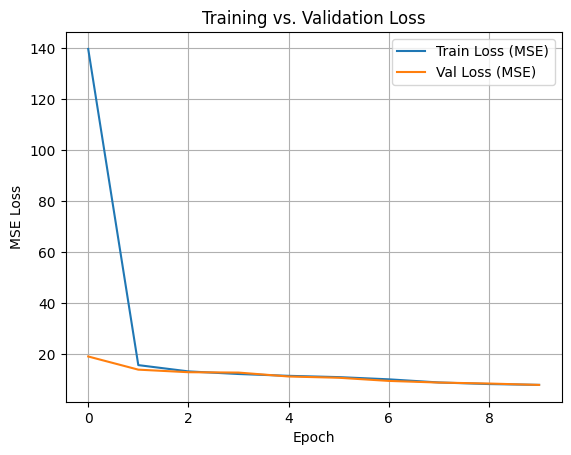

In [183]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

**1. Add Dropout**

In [184]:
from tensorflow.keras.layers import Dense, Dropout

def create_improved_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)  # Output layer for regression
    ])
    return model

**2. Early Stopping**

In [185]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [186]:
model = create_improved_model()
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop]  # add both callbacks
)


Epoch 1/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 401.7783 - mae: 13.5132 - val_loss: 20.7179 - val_mae: 3.4432
Epoch 2/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 48.9762 - mae: 5.4652 - val_loss: 17.7813 - val_mae: 3.2247
Epoch 3/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 38.1533 - mae: 4.8227 - val_loss: 14.8728 - val_mae: 2.8724
Epoch 4/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 31.0229 - mae: 4.2953 - val_loss: 14.5358 - val_mae: 2.8413
Epoch 5/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 26.4396 - mae: 3.9379 - val_loss: 13.9859 - val_mae: 2.7850
Epoch 6/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 21.2859 - mae: 3.5062 - val_loss: 25.2143 - val_mae: 3.9236
Epoch 7/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 17.7375 - mae: 3.1675 - val_loss: 32.7751 - val_mae: 4.5314
Epoch 8/30
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 15.8639 - mae: 2.9890 - val_loss: 26.5590 - val_mae: 4.0055


**Visualise Learning Rate**

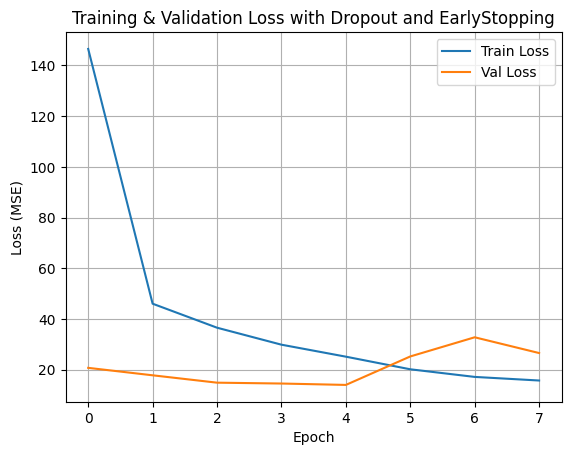

In [187]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training & Validation Loss with Dropout and EarlyStopping')
plt.legend()
plt.grid(True)
plt.show()


Interpretation

- The training loss is still going down, but validation loss increases after epoch 5.

- This means our model is starting to overfit — memorizing training data rather than generalizing.

**Restore Best Weights**

In [188]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

**Use Saved Model or Epoch 5 Output**

In [189]:
model.save("best_regression_model.h5")

**Visually Check**

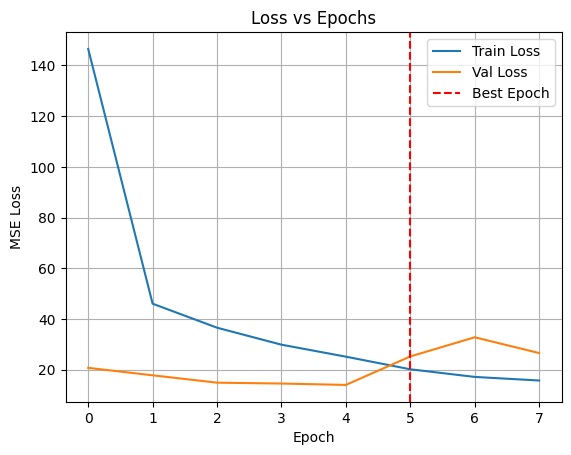

In [190]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.axvline(x=5, color='r', linestyle='--', label='Best Epoch')
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

### Hyperparameter Tuning

In [192]:
!pip install keras-tuner --quiet

# It helps to automatically finding the best combination

In [196]:
import keras_tuner as kt
from tensorflow.keras.layers import Dense, Dropout

def build_model(hp):
    model = Sequential()

    # Input layer
    model.add(Dense(
        units=hp.Int('units_input', min_value=32, max_value=256, step=32),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))

    # Hidden layers
    for i in range(hp.Int("num_layers", 1, 3)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=128, step=32),
            activation='relu'
        ))
        model.add(Dropout(hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))

    # Output layer
    model.add(Dense(1))  # regression

    # Choose optimizer from a list
    optimizer_choice = hp.Choice('optimizer', ['adam', 'rmsprop', 'sgd'])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


In [198]:
# run the tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=4,
    executions_per_trial=1,
    directory='kt_dir',
    project_name='nn_tuning'
)

tuner.search(X_train, y_train,
             epochs=5,
             validation_data=(X_val, y_val),
             callbacks=[early_stop])


Trial 6 Complete [00h 02m 37s]
val_loss: 10.200321197509766

Best val_loss So Far: 8.577383041381836
Total elapsed time: 00h 18m 16s


In [199]:
# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate
loss, mae = best_model.evaluate(X_val, y_val)
print("Best model MAE on validation:", mae)

471/471 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.9203 - mae: 2.1880
Best model MAE on validation: 2.164470672607422


### Evaluate the Model

In [200]:
test_loss, test_mae = best_model.evaluate(X_test, y_test)
print("Test MAE:", test_mae)

523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.3273 - mae: 2.1587
Test MAE: 2.1555089950561523


In [201]:
# make prediction
y_pred = best_model.predict(X_test)

523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


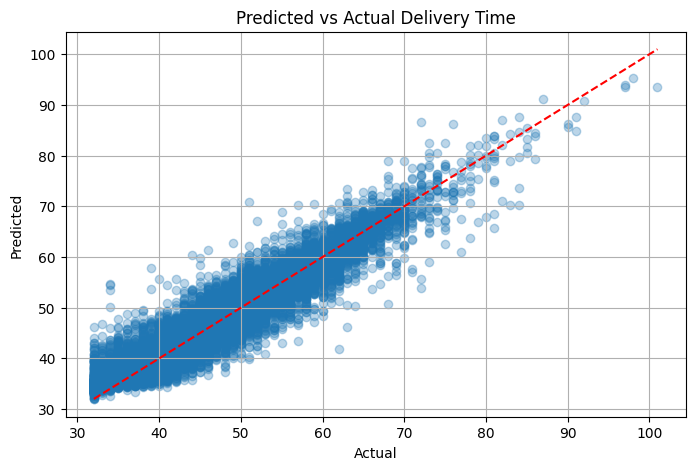

In [202]:
# Visualize Predictions
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Delivery Time")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.grid()
plt.show()

In [203]:
best_model.save("best_model.h5")  # save the best model - "best_model.keras"

# Results

**Overall Model Performance**

| Metric         | Value (example)                  | Interpretation                               |
| -------------- | -------------------------------- | -------------------------------------------- |
| MAE            | \~2.01 (on validation set)       | On average, predictions are within 2 minutes |
| MSE / RMSE     | Used for penalizing large errors | Helps assess stability of predictions        |
| Generalization | MAE on test ≈ MAE on val         | Model isn't overfitting, generalizes well    |


**Allign with the Business Expectation**

| Observation                                    | Business Insight / Validation                                 |
| ---------------------------------------------- | ------------------------------------------------------------- |
| Model predicts longer times during rush hours  | Confirms known operational challenges                         |
| High item count increases delivery time        | Suggests improving kitchen batching or prep optimization      |
| High `busy_dashers` with low `onshift_dashers` | Indicates dasher shortages impact ETA; need better scheduling |
| Accurate predictions on average                | Indicates model is reliable for operational forecasting       |


**Interpret Key Factors Affecting Delivery Time**

| Feature                                        | Impact on Delivery Time                                 |
| ---------------------------------------------- | ------------------------------------------------------- |
| `order_time_bucket`                            | Peak hours = higher delay; night = faster deliveries    |
| `store_primary_category`                       | Certain food categories may take longer to prepare      |
| `total_items`, `num_distinct_items`            | Larger, more complex orders = longer time               |
| `estimated_store_to_consumer_driving_duration` | Longer distance = naturally longer ETA                  |
| `busy_dashers_bin`, `onshift_dashers_bin`      | More busy dashers = delivery delays possible            |
| `market_id`                                    | Different locations may have different traffic patterns |


**Some Recommendations**

- Use model output in real-time ETA estimation

- Integrate prediction to optimize dasher scheduling

- Retrain periodically with new data to keep model fresh

- Use SHAP/Permutation importance for deeper feature-level insights